# Executive Order Analysis

Analysis over `data/analysis.db`: 1,534 Executive Orders, EO 12890 (1993-12-30) to
EO 14423 (2026-08-28), extracted by `openai/gpt-oss-120b` under prompt v7 (run 11).

Before quoting any number from this notebook, read
[INVESTIGATORS_CHEAT_SHEET.md](../INVESTIGATORS_CHEAT_SHEET.md). The four things it
says most often:

- **Recall was never measured.** "The model extracted X from 66% of orders" is
  supportable; "34% of orders have no X" is not.
- **Count agencies through `agency_taskings`**, ranked by distinct orders, excluding
  `kind IN ('collective', 'generic')`.
- **Filter relationships to `authoritative = 1`** (the `revocation_network` view
  already does).
- **Only `source_quote` is verified.** `summary` and `task` are model prose.

Every cell runs from the repository root with the project venv:

```sh
pip install -e ".[analysis]"
PYTHONPATH=src .venv/bin/jupyter lab notebooks/analysis.ipynb
```

## Setup

In [1]:
import re
import sqlite3
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))

from eo.grounding import is_grounded  # noqa: E402

DB = ROOT / "data" / "analysis.db"
con = sqlite3.connect(f"file:{DB}?mode=ro", uri=True)


def q(sql: str, **params) -> pd.DataFrame:
    """Run a query against analysis.db (read-only) and return a DataFrame."""
    return pd.read_sql_query(sql, con, params=params or None)


pd.set_option("display.max_colwidth", 80)
pd.set_option("display.width", 140)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["figure.figsize"] = (9, 4.5)

# Presidents in chronological order, for consistent axes and tables.
PRESIDENTS = q("SELECT president FROM orders GROUP BY 1 ORDER BY MIN(signing_date)")["president"].tolist()
SHORT = {"William J. Clinton": "Clinton", "George W. Bush": "G.W. Bush", "Barack Obama": "Obama",
         "Donald Trump": "Trump", "Joseph R. Biden Jr.": "Biden"}
print(DB, "opened read-only")

/Users/davidkolet-tassara/Documents/EO_Analysis/data/analysis.db opened read-only


## Sanity checks

The three checks the cheat sheet asks for before anything is published: which model
produced the data, that every stored quote really is in its order's text, and what is
already known to be imperfect.

In [2]:
q("SELECT run_id, model, prompt_version, ROUND(cost_usd, 2) AS cost_usd, coverage FROM run_metadata").T

,0
run_id,11
model,openai/gpt-oss-120b
prompt_version,v7
cost_usd,1.05
coverage,"Executive Orders with full text in the Federal Register API, which begins ~1..."


In [3]:
rows = con.execute(
    "SELECT c.source_quote, t.body_text FROM all_claims c JOIN order_text t USING (document_number)"
).fetchall()
grounded = sum(is_grounded(quote, body) for quote, body in rows)
print(f"{grounded} / {len(rows)} stored quotes appear in their order's text")
assert grounded == len(rows), "a stored quote is not in its source: the build is broken"

8989 / 8989 stored quotes appear in their order's text


In [4]:
q("SELECT kind, COUNT(*) AS items FROM review_queue GROUP BY 1 ORDER BY 2 DESC")

,kind,items
0,dropped_unverifiable,259
1,ungrounded_agencies_tasked,241
2,ungrounded_deadlines,156
3,ungrounded_authorities,77
4,ungrounded_relationships,66
5,relationship,63
6,other_without_reason,4


## Shape of the corpus

Orders per president, per *active* year. Trump's two terms are non-contiguous, so a
first-to-last date span would attribute 2021-24 to him and understate his rate.

In [5]:
shape = q("""
SELECT president,
       COUNT(*) AS orders,
       MIN(signing_date) AS first, MAX(signing_date) AS last,
       COUNT(DISTINCT substr(signing_date, 1, 4)) AS active_years,
       ROUND(COUNT(*) * 1.0 / COUNT(DISTINCT substr(signing_date, 1, 4)), 1) AS per_active_year
FROM orders GROUP BY president ORDER BY MIN(signing_date)
""")
shape

,president,orders,first,last,active_years,per_active_year
0,William J. Clinton,308,1993-12-30,2001-01-18,9,34.2
1,George W. Bush,291,2001-01-29,2009-01-16,9,32.3
2,Barack Obama,276,2009-01-21,2017-01-17,9,30.7
3,Donald Trump,497,2017-01-20,2026-08-28,7,71.0
4,Joseph R. Biden Jr.,162,2021-01-20,2025-01-19,5,32.4


In [6]:
q("""
SELECT 'orders' AS t, COUNT(*) AS n FROM orders
UNION ALL SELECT 'agencies_tasked', COUNT(*) FROM agencies_tasked
UNION ALL SELECT 'deadlines', COUNT(*) FROM deadlines
UNION ALL SELECT 'authorities', COUNT(*) FROM authorities
UNION ALL SELECT 'relationships (authoritative)', COUNT(*) FROM relationships WHERE authoritative = 1
UNION ALL SELECT 'agencies (canonical)', COUNT(*) FROM agencies
""").set_index("t")

,n
t,
orders,1534
agencies_tasked,3195
deadlines,2240
authorities,1707
relationships (authoritative),4849
agencies (canonical),598


## Analysis

Sections below are added as questions are asked. Each one states the query it rests on
and the caveat that applies to it.

### How often does each administration cancel a prior president's orders?

**What counts as cancelling.** The `revokes`, `rescinds` and `supersedes` relations,
in full or in part. `amends` is excluded: an amendment leaves the order in force.
The edge set is the authoritative one (`authoritative = 1`), so where the Federal
Register has a disposition note for a pair it is the single source, and the model's
edges add only pairs the Register is silent about. The Register also writes notes on
the *target* ("Revoked by: EO 13783"); a dozen of those have no matching note on the
revoking order, so they are flipped and added.

**Targets outside the corpus are kept, not dropped.** The `revocation_network` view
requires both ends to be orders in this database, which silently discards every
revocation of a pre-1994 order — all of Clinton's cancellations of Bush 41 and Reagan
orders, for instance. Here a target that names an EO number is attributed to its
signer by number range (from the Federal Register's disposition tables), whether or not
the order itself is in the corpus. Targets with no EO number — memoranda,
proclamations, determinations — are excluded.

**A cancellation cannot precede its target.** Fourteen Federal Register notes say
"Amends" or "Supersedes" where the dates show they mean "Amended by" or "Superseded
by" — EO 13286, the 2003 omnibus amendment, is written that way on eight orders it
amended. A forward edge whose target was signed *after* the acting order is therefore
dropped here; the later order's own note carries the relationship the right way round.

**Trump is split into two terms**, because "Trump 47 revokes a Trump 45 order" is the
same president cancelling his own order, and a single "Trump" row would hide it.
Each (order, target) pair counts once.

In [7]:
# Signer by EO number, for targets outside the corpus. First order of each
# president, from the Federal Register disposition tables.
FIRST_EO = [
    (6071, "F.D. Roosevelt"), (9538, "Truman"), (10432, "Eisenhower"),
    (10914, "Kennedy"), (11128, "L.B. Johnson"), (11452, "Nixon"), (11798, "Ford"),
    (11967, "Carter"), (12287, "Reagan"), (12668, "G.H.W. Bush"), (12834, "Clinton"),
]
ADMINS = ["Clinton", "G.W. Bush", "Obama", "Trump 45", "Biden", "Trump 47"]
SIGNERS = ["before F.D. Roosevelt"] + [name for _, name in FIRST_EO[:-1]] + ADMINS


def administration(president: str, signing_date: str) -> str:
    if president == "Donald Trump":
        return "Trump 45" if signing_date < "2025-01-20" else "Trump 47"
    return SHORT[president]


def signer_by_number(eo: int) -> str:
    name = "before F.D. Roosevelt"
    for first, who in FIRST_EO:
        if eo >= first:
            name = who
    return name


edges = q("""
WITH forward AS (
    SELECT document_number AS src, target_document_number AS tgt,
           target_eo_number AS tgt_eo, relation, in_part, source
    FROM relationships
    WHERE authoritative = 1 AND relation IN ('revokes', 'rescinds', 'supersedes')
),
inbound AS (
    SELECT r.target_document_number AS src, r.document_number AS tgt,
           o.eo_number AS tgt_eo, r.relation, r.in_part, r.source
    FROM relationships r JOIN orders o ON o.document_number = r.document_number
    WHERE r.authoritative = 1
      AND r.relation IN ('revoked_by', 'rescinded_by', 'superseded_by')
      AND r.target_document_number IS NOT NULL
)
SELECT e.src, e.tgt, e.tgt_eo, e.relation, e.in_part, e.source,
       s.eo_number AS src_eo, s.president AS src_president, s.signing_date AS src_date,
       t.president AS tgt_president, t.signing_date AS tgt_date
FROM (SELECT * FROM forward UNION ALL SELECT * FROM inbound) e
JOIN orders s ON s.document_number = e.src
LEFT JOIN orders t ON t.document_number = e.tgt
WHERE e.tgt_eo IS NOT NULL
""")
edges["relation"] = edges["relation"].str.replace("_by", "", regex=False).replace(
    {"revoked": "revokes", "rescinded": "rescinds", "superseded": "supersedes"})
# Federal Register rows first, so the surviving duplicate is the authoritative one.
edges = (edges.sort_values(["source", "in_part"], ascending=[True, True])
              .drop_duplicates(["src", "tgt_eo"]).copy())
inverted = edges.tgt_date.notna() & (edges.tgt_date > edges.src_date)
print(f"{int(inverted.sum())} edges dropped: the target was signed after the acting order")
edges = edges[~inverted].copy()
edges["actor"] = [administration(p, d) for p, d in zip(edges.src_president, edges.src_date)]
edges["target"] = [administration(p, d) if pd.notna(p) else signer_by_number(eo)
                   for p, d, eo in zip(edges.tgt_president, edges.tgt_date, edges.tgt_eo)]
edges["target_in_corpus"] = edges.tgt.notna()
edges["same_person"] = edges.target.str.split().str[0] == edges.actor.str.split().str[0]

print(f"{len(edges)} cancellations of numbered executive orders, "
      f"{edges.target_in_corpus.sum()} with the target in the corpus, "
      f"{(~edges.target_in_corpus).sum()} attributed by EO number; "
      f"{int(edges.in_part.sum())} are in part")
edges.relation.value_counts()

6 edges dropped: the target was signed after the acting order
613 cancellations of numbered executive orders, 478 with the target in the corpus, 135 attributed by EO number; 33 are in part


relation
revokes       496
supersedes    111
rescinds        6
Name: count, dtype: int64

Per administration: how many cancellations, how many of them fell on another
president's orders, and the rate per active year (Trump 47 is a partial term).

In [8]:
active_years = q("""
SELECT president, signing_date FROM orders
""")
active_years["actor"] = [administration(p, d) for p, d in zip(active_years.president, active_years.signing_date)]
active_years = active_years.assign(year=active_years.signing_date.str[:4]).groupby("actor").year.nunique()

by_actor = (edges.groupby("actor")
                 .agg(cancellations=("tgt_eo", "size"),
                      prior_president=("same_person", lambda s: int((~s).sum())),
                      own=("same_person", "sum"),
                      target_outside_corpus=("target_in_corpus", lambda s: int((~s).sum())))
                 .reindex(ADMINS))
by_actor["active_years"] = active_years.reindex(ADMINS)
by_actor["prior_per_active_year"] = (by_actor.prior_president / by_actor.active_years).round(1)
by_actor

,cancellations,prior_president,own,target_outside_corpus,active_years,prior_per_active_year
actor,,,,,,
Clinton,112,52,60,71,9,5.8
G.W. Bush,116,83,33,43,9,9.2
Obama,87,57,30,6,9,6.3
Trump 45,56,42,14,6,5,8.4
Biden,105,96,9,1,5,19.2
Trump 47,137,132,5,8,2,66.0


Whose orders each administration cancelled. Rows are the acting administration;
columns are the signer of the cancelled order, oldest first. Signers left of Clinton are
attributed by EO number, since their orders are outside the corpus.

In [9]:
matrix = (edges.pivot_table(index="actor", columns="target", values="tgt_eo", aggfunc="size", fill_value=0)
               .reindex(index=ADMINS, columns=[s for s in SIGNERS if s in set(edges.target)], fill_value=0))
matrix

target,before F.D. Roosevelt,F.D. Roosevelt,Truman,Eisenhower,Kennedy,L.B. Johnson,Nixon,Ford,Carter,Reagan,G.H.W. Bush,Clinton,G.W. Bush,Obama,Trump 45,Biden,Trump 47
actor,,,,,,,,,,,,,,,,,
Clinton,1,3,1,2,3,3,1,1,6,17,14,60,0,0,0,0,0
G.W. Bush,0,0,0,1,0,2,2,5,0,11,14,48,33,0,0,0,0
Obama,0,0,1,1,0,0,0,1,1,1,1,7,44,30,0,0,0
Trump 45,1,1,0,1,0,1,1,0,0,0,1,2,3,31,14,0,0
Biden,0,0,0,1,0,0,0,0,0,0,0,3,4,12,76,9,0
Trump 47,1,0,0,0,0,2,1,0,3,1,0,3,4,5,1,112,4


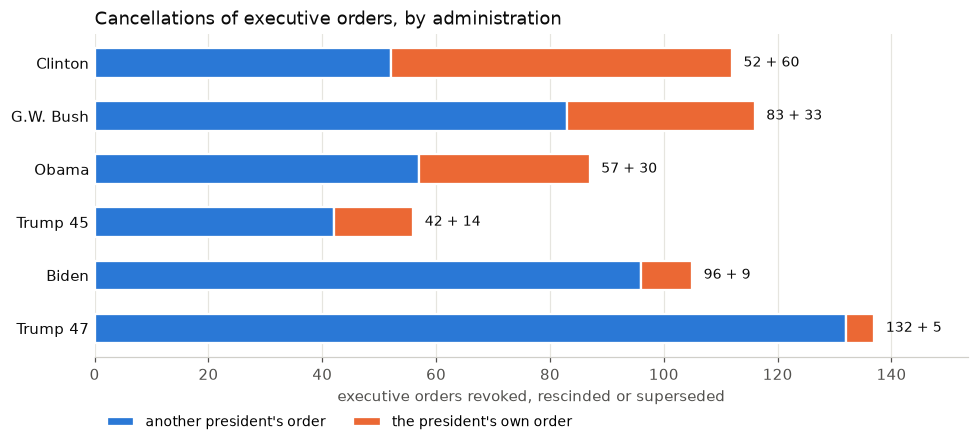

In [10]:
# Series colours: categorical slots 1 and 2 of the reference palette, validated as an
# adjacent pair (CVD dE >= 8, normal-vision dE >= 15).
BLUE, ORANGE, INK, MUTED = "#2a78d6", "#eb6834", "#0b0b0b", "#52514e"

fig, ax = plt.subplots(figsize=(9, 4.2))
rows = by_actor[::-1]  # chronological top to bottom
y = range(len(rows))
ax.barh(y, rows.prior_president, height=0.55, color=BLUE, label="another president's order",
        edgecolor="white", linewidth=1.5)
ax.barh(y, rows.own, height=0.55, left=rows.prior_president, color=ORANGE,
        label="the president's own order", edgecolor="white", linewidth=1.5)
for i, (prior, own) in enumerate(zip(rows.prior_president, rows.own)):
    ax.text(prior + own + 2, i, f"{int(prior)} + {int(own)}", va="center", fontsize=9, color=INK)
ax.set_yticks(list(y), rows.index)
ax.set_xlabel("executive orders revoked, rescinded or superseded", color=MUTED)
ax.set_title("Cancellations of executive orders, by administration", loc="left", fontsize=12, color=INK)
ax.set_xlim(0, (rows.prior_president + rows.own).max() * 1.12)
ax.legend(frameon=False, loc="upper left", bbox_to_anchor=(0, -0.14), ncol=2, fontsize=9)
for side in ("top", "right", "left"):
    ax.spines[side].set_visible(False)
ax.spines["bottom"].set_color("#d0cfc9")
ax.tick_params(axis="y", length=0, colors=INK)
ax.tick_params(axis="x", colors=MUTED)
ax.xaxis.grid(True, color="#e6e5df", linewidth=0.8)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

**Caveats that apply to these numbers.**

- The Federal Register is the authoritative source and its disposition notes are the
  bulk of the edge set. The model's additions are precision-checked (every quote is
  verified) but recall was never measured, so an administration's count is a floor.
- Cancelling *in part* counts as a cancellation. So does `supersedes`.
- Memoranda, proclamations and orders the source names without a number are excluded.
  For the model's edges that is most of what it found: it often cited a section or a
  memorandum rather than an EO number.
- Attribution by EO number for pre-1994 targets rests on the published first-order
  number of each president. A wrong boundary would move a few edges between adjacent
  presidents, never between the "prior" and "own" columns.